In [1]:
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
import matplotlib 
%matplotlib inline

In [2]:
! pwd

/Users/alyulina/Projects/Cancer/Code


In [4]:
# data from https://docs.google.com/spreadsheets/d/100QgXtkE5FHj-EFaa64HkjYu8EddSB07/edit#gid=1566829729

# cell line IDs
clIDs = ['AACC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GATC', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TGCT', 'TGTG', 'TTCC', 'TTGG']

# cell lines; added numbers (1 and 2) to cell lines w/ identical names
cell_lines = ['mT4-2D', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_ine', 'Spike-in1', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'Spike-in2', 'Spike-in3', 'FC1242', 'UN-KPC_961']

clID_dict = dict(zip(clIDs, cell_lines))
cell_line_dict = dict(zip(cell_lines, clIDs))

# samples sequenced in the first run
samples = ['SK1_' + '{:0.0f}'.format(i) for i in range(1, 45)]
lung_weights = [0.22, 0.1842, 0.182, 0.461, 0.256, 0.287, 0.437, 0.18, 0.181, 0.222, 0.2606, 0.213, 0.166, 0.213, 0.232, 0.205, 0.189, 0.162, 0.17, 0.171, 0.285, 0.158, 0.215, 0.27, 0.428, 0.304, 0.305, 0.298, 0.292, 0.24, 0.378, 0.334, 0.314, 0.56, 0.414, 0.36, 0.406, 0.219, 0.434, 0.354, 0.276, 0.294, 0.313, 0.329]
lung_weight_dict = dict(zip(samples, lung_weights))

In [39]:
sample_clID_counts = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples):
    
    sample_clID_counts.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        # print(clID_bc, count)
        
        if int(count) < 2: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [40]:
# cancer reads per sample
n_reads_cancer_cells = {}
for i, sample in enumerate(samples):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike':
            counts += sum([x[-1] for x in sample_clID_counts[i][j]])
            
    n_reads_cancer_cells[sample] = counts     

In [41]:
# spike-in reads per sample
n_reads_spiked = {}
for i, sample in enumerate(samples):
    
    counts = [0, 0, 0]
    for j in clIDs:
        if clID_dict.get(j) == 'Spike-in1':
            counts[0] += sum([x[-1] for x in sample_clID_counts[i][j]])
        elif clID_dict.get(j) == 'Spike-in2':
            counts[1] += sum([x[-1] for x in sample_clID_counts[i][j]])
        elif clID_dict.get(j) == 'Spike-in3':
            counts[2] += sum([x[-1] for x in sample_clID_counts[i][j]])

    n_reads_spiked[sample] = counts     

Text(0.5, 1.0, '# of cancer cells per sample \n (from spike-in 1 read counts)')

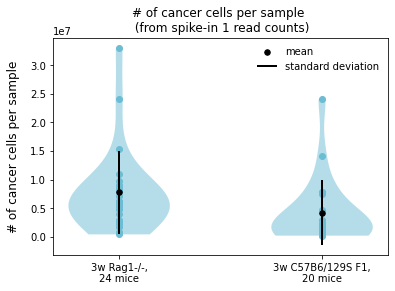

In [108]:
spike_id = 0 # can be 0 or 2
data = [[n_reads_cancer_cells.get(i) * (50000) / n_reads_spiked.get(i)[spike_id] for i in samples if int(i.split('_')[-1]) < 25],
        [n_reads_cancer_cells.get(i) * (50000) / n_reads_spiked.get(i)[spike_id] for i in samples if int(i.split('_')[-1]) > 24]]

violins = plt.violinplot(data, vert=True, showmedians=False, showextrema=False)
plt.scatter([1 for x in data[0]], data[0], color='#6cbdd4')
plt.scatter([2 for x in data[1]], data[1], color='#6cbdd4')

means = [np.mean(x) for x in data]
sems = [sp.stats.sem(x) for x in data]
stds = [np.std(x) for x in data]
plt.scatter([1, 2], means, marker='o', color='black', s=30, zorder=3, label='mean')
plt.vlines([1, 2], [x - y for x, y in zip(means, stds)], [x + y for x, y in zip(means, stds)], color='black', lw=2, zorder=2, label='standard deviation')

#for i, x in enumerate(means):
#    plt.text(i + 1.05, x, '~' + '{0:.0f}'.format(x * 1e-3) + ',' + '000')

formatter = matplotlib.ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x/1e5))
plt.xticks([1, 2], ['3w Rag1-/-,\n24 mice', '3w C57B6/129S F1,\n20 mice'])
#plt.yticks([0, 200000, 400000, 600000, 800000], ['0', '200' + ',' + '000', '400' + ',' + '000', '600' + ',' + '000', '800' + ',' + '000'])
plt.ylabel('# of cancer cells per sample', fontsize=12, labelpad=10)
plt.legend(frameon=False, bbox_to_anchor=(1, 1))

for pc in violins['bodies']:
    pc.set_facecolor('#6cbdd4')
    pc.set_alpha(0.5)

plt.title('# of cancer cells per sample \n (from spike-in ' + str(spike_id + 1) + ' read counts)')

# plt.savefig('total_n_cells_per_mouse_spike-in_' + str(spike_id + 1) + '.png', dpi=300, bbox_inches='tight')

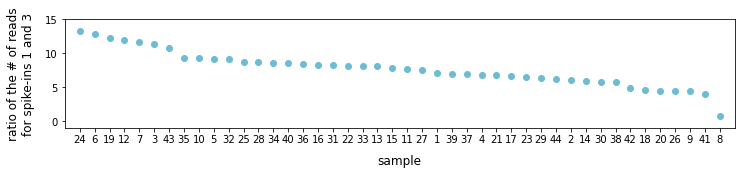

In [154]:
plt.figure(figsize=(12, 2))

data = sorted([[i, n_reads_spiked.get(samples[i])[0] / n_reads_spiked.get(samples[i])[2]] for i in range(len(samples))],
               key = lambda x: x[-1], reverse=True)
plt.scatter(range(len(data)), [x[-1] for x in data], color='#6cbdd4')
plt.xticks(range(len(data)), [x[0] + 1 for x in data]);

plt.ylabel('ratio of the # of reads\nfor spike-ins 1 and 3', fontsize=12, labelpad=10)
plt.xlabel('sample', fontsize=12, labelpad=10)

plt.ylim(-1, 15)
plt.xlim(-1, len(data))

# plt.savefig('spike_ins_read_count_ratio.png', dpi=300, bbox_inches='tight')

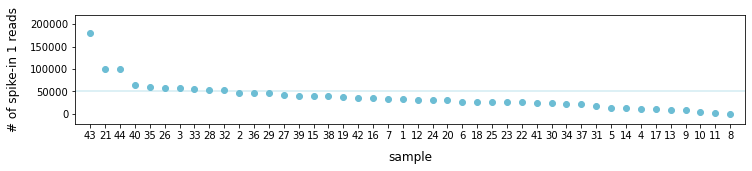

In [161]:
spike_id = 0
plt.figure(figsize=(12, 2))

data = sorted([[i, n_reads_spiked.get(samples[i])[spike_id]] for i in range(len(samples))],
               key = lambda x: x[-1], reverse=True)
plt.scatter(range(len(data)), [x[-1] for x in data], color='#6cbdd4')
plt.axhline(y=50000, color='#6cbdd4', alpha=0.3)

plt.xticks(range(len(data)), [x[0] + 1 for x in data]);

plt.ylabel('# of spike-in ' + str(spike_id + 1) + ' reads', fontsize=12, labelpad=10)
plt.xlabel('sample', fontsize=12, labelpad=10)

if spike_id == 0:
    plt.ylim(-22000, 220000)
elif spike_id == 2:
    plt.ylim(-2000, 22000)
plt.xlim(-1, len(data))

# plt.savefig('n_spike-in_' + str(spike_id + 1) + '_reads.png', dpi=300, bbox_inches='tight')

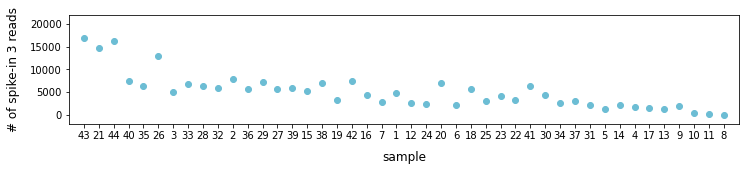

In [164]:
plt.figure(figsize=(12, 2))

ids = [y[0] for y in sorted([[i, n_reads_spiked.get(samples[i])[0]] for i in range(len(samples))],
       key = lambda x: x[-1], reverse=True)]

data = [[i, n_reads_spiked.get(samples[i])[2]] for i in ids]

plt.scatter(range(len(data)), [x[-1] for x in data], color='#6cbdd4')
plt.axhline(y=50000, color='#6cbdd4', alpha=0.3)

plt.xticks(range(len(data)), [x[0] + 1 for x in data]);

plt.ylabel('# of spike-in ' + str(2 + 1) + ' reads', fontsize=12, labelpad=10)
plt.xlabel('sample', fontsize=12, labelpad=10)

plt.ylim(-2000, 22000)
plt.xlim(-1, len(data))

# plt.savefig('n_spike-in_' + str(2 + 1) + '_reads.png', dpi=300, bbox_inches='tight')

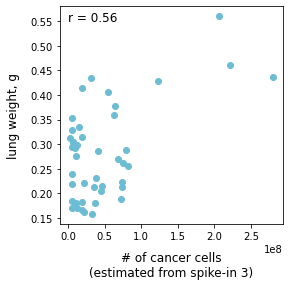

In [171]:
plt.figure(figsize=(4, 4))

spike_id = 2 # can be 0 or 2
data = sorted([[lung_weight_dict.get(i), n_reads_cancer_cells.get(i) * (50000) / n_reads_spiked.get(i)[spike_id]] for i in samples],
              key = lambda x: x[-1])

plt.scatter([x[1] for x in data], [x[0] for x in data], color='#6cbdd4')

pearson_r = sp.stats.pearsonr([x[1] for x in data], [x[0] for x in data])
plt.text(0, 0.55, 'r = ' + '{0:.2f}'.format(pearson_r[0]), size=12)

plt.ylabel('lung weight, g', fontsize=12, labelpad=10)
plt.xlabel('# of cancer cells\n(estimated from spike-in ' + str(spike_id + 1) + ')', fontsize=12, labelpad=10)

plt.savefig('n_cells_lung_weight_' + str(spike_id + 1) + '.png', dpi=300, bbox_inches='tight')

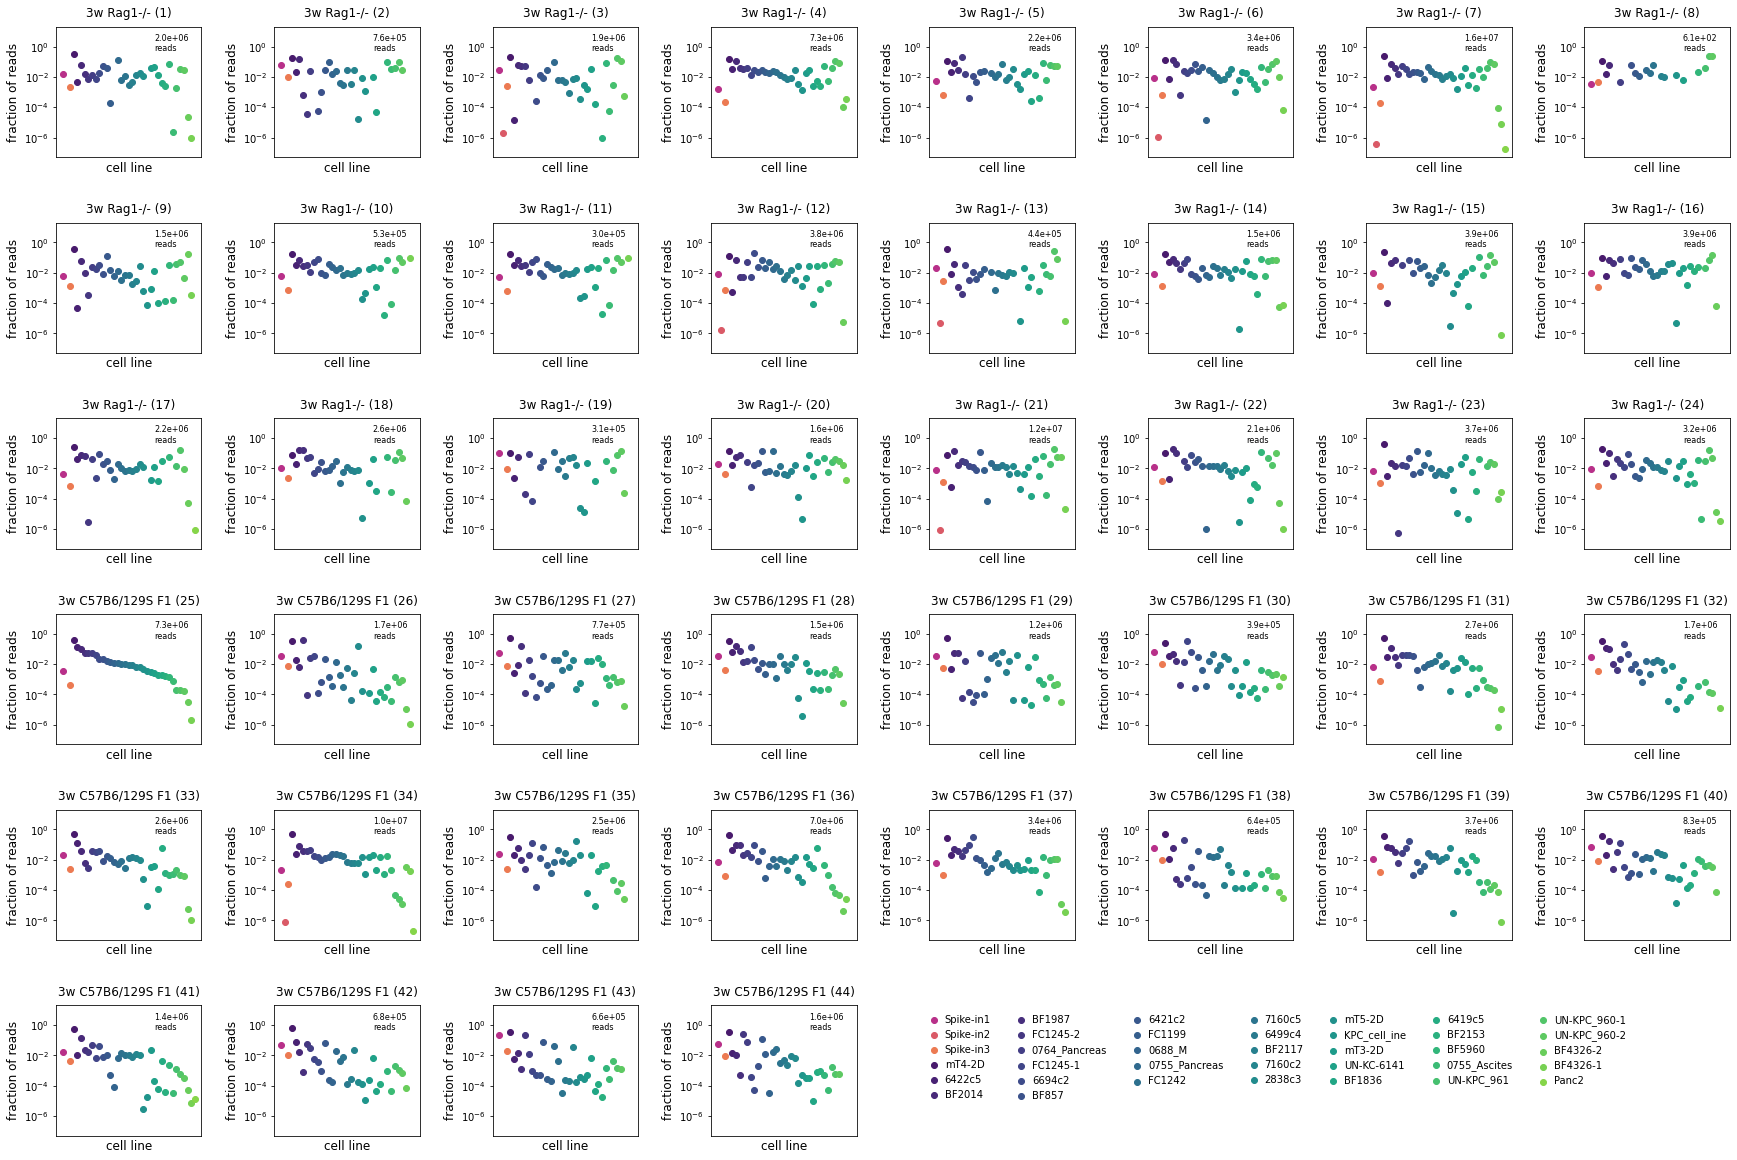

In [315]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(samples)), 
                                       cmap=plt.get_cmap('viridis'))

plasma = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=5), 
                                       cmap=plt.get_cmap('plasma'))

colors = ['#b83089', '#da5a67', '#ec7a52'] # for spike-ins

plt.figure(figsize=(30, 24))

grid = gridspec.GridSpec(ncols=8, nrows=7,
                         width_ratios=[1, 1, 1, 1, 1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1, 1, 1, 1, 1], hspace=0.5)

c = 0
cell_line_fracs_sample = []
for i in range(len(samples)):
    
    total_coverage = n_reads_cancer_cells[samples[i]] + sum(n_reads_spiked[samples[i]])
    
    plt.subplot(grid[c // 8, c % 8])
    
    
    # cell line order based on sample 24
    order = [23, 33, 34, 0, 20, 17, 6, 21, 29, 9, 3, 5, 30, 2, 8, 15, 35, 4, 19, 11, 1, 32, 28, 22, 27, 26, 16, 12, 25, 18, 31, 36, 14, 24, 13, 10, 7]
    fracs = {}
    n_cells_total = 0
    spike_counts = []
    for count, j in enumerate(order):
        
        if cell_lines[j][:5] != 'Spike':
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts[i][clIDs[j]]])
            n_cells_total += n_bc_total
            plt.scatter(count, n_bc_total / total_coverage, label=cell_lines[j], color=viridis.to_rgba(count))
            fracs[cell_lines[j]] = n_bc_total / total_coverage
            
        
        elif cell_lines[j][:5] == 'Spike':
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts[i][clIDs[j]]])
            plt.scatter(count, n_bc_total / total_coverage, label=cell_lines[j], color=colors[count])
            fracs[cell_lines[j]] = n_bc_total / total_coverage
            spike_counts.append(n_bc_total)
        
    # print(spike_counts[0] / spike_counts[2])
    cell_line_fracs_sample.append(fracs)

    plt.yscale('log'); plt.minorticks_off()
    plt.ylim(5e-8, 20)
    # plt.xlim(0, 200)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    plt.xticks([], [])

   
    plt.xlabel('cell line', fontsize=12)
    plt.ylabel('fraction of reads', fontsize=12)
    
    plt.text(25, 0.5, '{:.1e}'.format(n_cells_total) + '\nreads', fontsize=8, color='black')

    
    if i < 24:
        title = '3w Rag1-/- (' + str(i + 1) + ')'
    else:
        title = '3w C57B6/129S F1 (' + str(i + 1) + ')'
    
    plt.title(title, fontsize=12, pad=10)
    
    if i == len(samples) - 1:
        plt.legend(frameon=False, ncol=7, handletextpad=0.1, bbox_to_anchor=(1.4, 1))
    
    c += 1
    
# plt.savefig('fraction_of_reads_per_cell_line.png', dpi=300, bbox_inches='tight')

In [220]:
cell_line_fracs_rag1 = {}
cell_line_fracs_f1 = {}

for i in cell_lines:
    
    cell_line_fracs_rag1[i] = 0
    cell_line_fracs_f1[i] = 0
    
    for j in range(0, 24):
        
        if j == 7 or j == 10: # excluding samples 8 and 11
            continue
            
        cell_line_fracs_rag1[i] += cell_line_fracs_sample[j][i] / (len(range(0, 24)) - 2)
        
    for j in range(24, 44):
            
        cell_line_fracs_f1[i] += cell_line_fracs_sample[j][i] / len(range(24, 44))
        

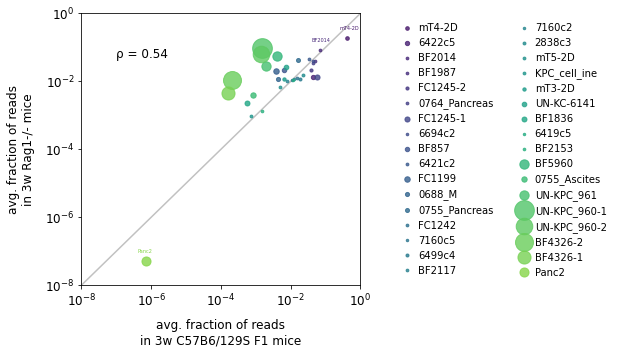

In [298]:
plt.figure(figsize=(5, 5))

x = []; y = []
for count, i in enumerate(order):
    if count < 3: # skipping spike-ins
        continue
        
    diff = max([cell_line_fracs_f1[cell_lines[i]], cell_line_fracs_rag1[cell_lines[i]]]) / min([cell_line_fracs_f1[cell_lines[i]], cell_line_fracs_rag1[cell_lines[i]]]) 
    plt.scatter(cell_line_fracs_f1[cell_lines[i]], cell_line_fracs_rag1[cell_lines[i]], color=viridis.to_rgba(count), label=cell_lines[i], s=6 * diff, alpha=0.8)
    
    if count in [3, 5, 36]:
        plt.text(0.6 * cell_line_fracs_f1[cell_lines[i]], 1.8 * cell_line_fracs_rag1[cell_lines[i]],
                cell_lines[i], color=viridis.to_rgba(count), size=5)
        
    x.append(cell_line_fracs_f1[cell_lines[i]])
    y.append(cell_line_fracs_rag1[cell_lines[i]])
    
plt.plot([1e-10, 10], [1e-10, 10], color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(x, y)
plt.text(1e-7, 0.05, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-8, 1);
plt.ylim(1e-8, 1);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. fraction of reads\nin 3w C57B6/129S F1 mice', fontsize=12, labelpad=10);
plt.ylabel('avg. fraction of reads\nin 3w Rag1-/- mice', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

plt.savefig('avg_read_frac_per_cell_line.png', dpi=300, bbox_inches='tight')